# MIVA-KNIGHT — Pipeline D: CREMA-D Audio-Visual Multimodal Emotion Recognition
## Cross-Modal InfoNCE | Wav2Vec Cache | 7,442 .mp4 clips

---

### Architecture

```
CREMA-D clip
    |
    +-- Audio .wav
    |       | Wav2Vec 2.0 (frozen) -> 768d mean-pooled  [cached once]
    |       v
    |   AudioProjection (768->512)  TRAINS
    |       |
    |       v  InfoNCE: audio_N <-> video_N (same clip = positive)
    |   512d audio emb <-------> 512d video emb
    |                                   ^
    +-- Middle video frame              |
            | ResNet-50 (frozen) -> 2048d  [cached once]
            v
        VideoFrameProjection (2048->512)  TRAINS
```

### Why this architecture works (and why it ran to epoch 16)

Backbones are **fully frozen**. Wav2Vec and ResNet features are extracted
**once** and cached — AudioProjection and VideoFrameProjection are small
projection heads that train on top of those fixed features.

Peak RAM: ~2GB (just the cache + two small proj heads). No crashes.
Per epoch: ~3 min (just proj head math, no backbone forward pass per batch).

### Key numbers

| Setting | Value |
|---|---|
| Epochs | 13 |
| Batch size | 32 |
| LR | 1e-4 (5e-5 if warm-started from Pipeline C) |
| Warm-start | Pipeline C weights loaded if available |

**Run every cell top to bottom. Do not skip.**

In [1]:
!pip install -q datasets transformers torchaudio torchvision soundfile librosa opencv-python
print("Packages installed")

Packages installed


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import json, os, io, time, warnings
from tqdm.auto import tqdm
from collections import defaultdict, Counter

import torchaudio
import torchvision.models as models
from torchvision import transforms
from torchvision.models import ResNet50_Weights
from transformers import Wav2Vec2Model, Wav2Vec2Processor
from PIL import Image
import soundfile as sf

try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device}')
if device == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch : {torch.__version__}')
print("All imports complete")

Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
PyTorch : 2.10.0+cu128
All imports complete


## Cell 3: Mount Drive & Set Config

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# PyTorch 2.6 patch
import torch as _torch
_orig_load = _torch.load
def _patched_load(f, *args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_load(f, *args, **kwargs)
_torch.load = _patched_load
print("PyTorch 2.6 patch applied")

# Auto-detect project base
POSSIBLE_BASES = [
    '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project ',
    '/content/drive/MyDrive/Oluwakayode Soyinka IT 581 Project',
]
shortcut_root = '/content/drive/.shortcut-targets-by-id'
if os.path.exists(shortcut_root):
    for sid in os.listdir(shortcut_root):
        sp = os.path.join(shortcut_root, sid)
        if os.path.isdir(sp):
            for folder in os.listdir(sp):
                if 'soyinka' in folder.lower() or '581' in folder.lower():
                    POSSIBLE_BASES.append(os.path.join(sp, folder))

PROJECT_BASE = None
for path in POSSIBLE_BASES:
    if os.path.exists(path) and os.path.exists(os.path.join(path, 'models')):
        PROJECT_BASE = path
        break

if PROJECT_BASE is None:
    raise RuntimeError('Project folder not found.')
print(f'Project base: {PROJECT_BASE}')

CREMA_DIR       = os.path.join(PROJECT_BASE, 'Data', 'Crema-d')
CACHE_DIR       = os.path.join(PROJECT_BASE, 'Data', 'crema_embeddings_cache')
CACHE_FILE      = os.path.join(CACHE_DIR, 'crema_cache.pt')
PIPELINE_D_DIR  = os.path.join(PROJECT_BASE, 'models', 'miva_knight_pipelineD')
PIPELINE_C_DIR  = os.path.join(PROJECT_BASE, 'models', 'miva_knight_pipelineC')
CHECKPOINT      = os.path.join(PIPELINE_D_DIR, 'checkpoint_pipelineD_latest.pth')

for d in [CACHE_DIR, PIPELINE_D_DIR]:
    os.makedirs(d, exist_ok=True)

# Config
EMBED_DIM     = 512
WAV2VEC_DIM   = 768
RESNET_DIM    = 2048
NUM_EPOCHS    = 13
BATCH_SIZE    = 32
TEMPERATURE   = 0.07
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 0.01

assert os.path.exists(CREMA_DIR), f'Crema-d not found at: {CREMA_DIR}'
actor_dirs = sorted([d for d in os.listdir(CREMA_DIR)
                     if os.path.isdir(os.path.join(CREMA_DIR, d))])
total_mp4 = sum(
    len([f for f in os.listdir(os.path.join(CREMA_DIR, a)) if f.endswith('.mp4')])
    for a in actor_dirs)
print(f'CREMA-D : {len(actor_dirs)} actors | {total_mp4:,} .mp4 files')
print(f'Epochs  : {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print(f'Cache   : {CACHE_FILE}')

Mounted at /content/drive
PyTorch 2.6 patch applied
Project base: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project 
CREMA-D : 91 actors | 7,442 .mp4 files
Epochs  : 13 | Batch: 32 | LR: 0.0001
Cache   : /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/crema_embeddings_cache/crema_cache.pt


## Cell 4: Filename Parser, Emotion Mapping & Frame Extraction

In [4]:
CREMA_EMOTION_MAP = {
    'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fearful',
    'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad',
}
CREMA_EMOTIONS_6       = ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']
CREMA_EMOTION_TO_LABEL = {e: i for i, e in enumerate(CREMA_EMOTIONS_6)}
CREMA_LABEL_TO_EMOTION = {i: e for i, e in enumerate(CREMA_EMOTIONS_6)}

FRAME_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
GRAY_FRAME = FRAME_TRANSFORM(Image.new('RGB', (224, 224), 'gray'))


def parse_crema_filename(filename):
    # Handles both 4-part (1001_DFA_ANG_XX.mp4) and
    # 5-part (1001_DFA_ANG_XX_01.mp4) formats
    stem  = os.path.splitext(os.path.basename(filename))[0]
    parts = stem.split('_')
    if len(parts) not in (4, 5):
        return None
    actor_str, sentence, emotion_code = parts[0], parts[1], parts[2]
    if emotion_code not in CREMA_EMOTION_MAP:
        return None
    try:
        actor_id = int(actor_str)
    except ValueError:
        return None
    return {
        'actor_id': actor_id,
        'sentence': sentence,
        'emotion' : CREMA_EMOTION_MAP[emotion_code],
        'stem'    : stem,
    }


def extract_middle_frame(mp4_path):
    if not CV2_AVAILABLE:
        return GRAY_FRAME.clone(), False
    try:
        cap   = cv2.VideoCapture(mp4_path)
        if not cap.isOpened():
            return GRAY_FRAME.clone(), False
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            return GRAY_FRAME.clone(), False
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, total // 2))
        ret, frame = cap.read()
        cap.release()
        if not ret or frame is None:
            return GRAY_FRAME.clone(), False
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return FRAME_TRANSFORM(Image.fromarray(rgb)), True
    except Exception:
        return GRAY_FRAME.clone(), False


# Count all valid clips
all_mp4 = []
emotion_counts = Counter()
for actor_dir in actor_dirs:
    actor_path = os.path.join(CREMA_DIR, actor_dir)
    for f in sorted(os.listdir(actor_path)):
        if not f.endswith('.mp4'):
            continue
        meta = parse_crema_filename(f)
        if meta:
            all_mp4.append((os.path.join(actor_path, f), meta))
            emotion_counts[meta['emotion']] += 1

print(f'Valid .mp4 files: {len(all_mp4):,}')
print(f'\nEmotion distribution:')
for emotion in CREMA_EMOTIONS_6:
    ct  = emotion_counts.get(emotion, 0)
    bar = chr(9608) * (ct // 80)
    print(f'  {emotion:<10}: {ct:5d}  {bar}')

Valid .mp4 files: 7,442

Emotion distribution:
  angry     :  1271  ███████████████
  disgust   :  1271  ███████████████
  fearful   :  1271  ███████████████
  happy     :  1271  ███████████████
  neutral   :  1087  █████████████
  sad       :  1271  ███████████████


## Cell 5: Wav2Vec Encoder (Frozen)

Fully frozen — all 94M params fixed.
Used only during the one-time cache extraction.
Freed from VRAM immediately after caching.
Not present during training at all.

In [5]:
class Wav2VecEncoder(nn.Module):
    def __init__(self, model_name='facebook/wav2vec2-base-960h'):
        super().__init__()
        print(f'  Loading {model_name}...')
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model     = Wav2Vec2Model.from_pretrained(model_name)
        for p in self.model.parameters():
            p.requires_grad = False
        self.model.eval()
        print('  Wav2Vec 2.0 frozen (94M params, 0 trainable)')

    @torch.no_grad()
    def encode_file(self, wav_path):
        waveform, sr = torchaudio.load(wav_path)
        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        wave_np = waveform.squeeze(0).numpy()
        inputs  = self.processor(
            wave_np, sampling_rate=16000,
            return_tensors='pt', padding=True
        )
        iv  = inputs.input_values.to(next(self.model.parameters()).device)
        out = self.model(iv)
        return out.last_hidden_state.mean(dim=1).cpu()   # [1, 768]


print("Wav2VecEncoder defined (used only for cache extraction)")

Wav2VecEncoder defined (used only for cache extraction)


## Cell 6: Extract & Cache

One-time extraction (~15-20 min). After that, loads from Drive instantly.

**Cache format:**
```python
{
  '1001_DFA_ANG_XX': {
      'audio_emb'   : tensor [768],       # Wav2Vec features
      'frame_tensor': tensor [3,224,224], # middle frame (gray if no video)
      'emotion'     : 'angry',
      'label'       : 0,
      'has_video'   : True,
  }
}
```

After extraction, Wav2Vec is deleted from VRAM — only proj heads remain during training.

In [6]:
def extract_and_cache():
    # Load existing cache
    if os.path.exists(CACHE_FILE):
        print(f'Cache found - loading...')
        cache = torch.load(CACHE_FILE, map_location='cpu')
        if len(cache) > 100:
            sample  = next(iter(cache.values()))
            adim    = sample['audio_emb'].shape[0]
            n_video = sum(1 for v in cache.values() if v.get('has_video', False))
            print(f'  {len(cache):,} entries | audio: {adim}d | with_video: {n_video}')
            assert adim == 768, f'Cache audio dim={adim}, expected 768. Delete {CACHE_FILE} and rerun.'
            return cache
        else:
            print(f'  Cache too small ({len(cache)}) - re-extracting')

    print(f'Extracting {len(all_mp4):,} clips (one-time ~15-20 min)...')
    wav2vec = Wav2VecEncoder().to(device)

    cache      = {}
    skipped    = 0
    video_ok   = 0
    emotion_ct = Counter()

    for mp4_path, meta in tqdm(all_mp4, desc='Extracting'):
        # Audio: Wav2Vec encode
        try:
            audio_emb = wav2vec.encode_file(mp4_path).squeeze(0)  # [768]
        except Exception:
            skipped += 1
            continue

        # Video: middle frame
        frame_tensor, frame_ok = extract_middle_frame(mp4_path)
        if frame_ok:
            video_ok += 1

        cache[meta['stem']] = {
            'audio_emb'   : audio_emb,
            'frame_tensor': frame_tensor,
            'emotion'     : meta['emotion'],
            'label'       : CREMA_EMOTION_TO_LABEL[meta['emotion']],
            'actor_id'    : meta['actor_id'],
            'has_video'   : frame_ok,
        }
        emotion_ct[meta['emotion']] += 1

    # Free Wav2Vec VRAM before training
    del wav2vec
    if device == 'cuda':
        torch.cuda.empty_cache()

    torch.save(cache, CACHE_FILE)
    print(f'\nCache saved: {CACHE_FILE}')
    print(f'  Total     : {len(cache):,}')
    print(f'  Skipped   : {skipped}')
    print(f'  Audio dim : 768d')
    print(f'  Video ok  : {video_ok:,} / {len(cache):,}')
    print(f'  Emotions  : {dict(sorted(emotion_ct.items()))}')
    return cache


crema_cache = extract_and_cache()

n_with_video = sum(1 for v in crema_cache.values() if v['has_video'])
CROSS_MODAL  = n_with_video / max(len(crema_cache), 1) >= 0.5
print(f'\nMode: {"cross-modal InfoNCE" if CROSS_MODAL else "audio-only SupCon"}')
print(f'  Video frames: {n_with_video:,} / {len(crema_cache):,}')

if device == 'cuda':
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'  VRAM free after cache load: {free/1e9:.1f} / {total/1e9:.1f} GB')

Extracting 7,442 clips (one-time ~15-20 min)...
  Loading facebook/wav2vec2-base-960h...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Wav2Vec 2.0 frozen (94M params, 0 trainable)


Extracting:   0%|          | 0/7442 [00:00<?, ?it/s]


Cache saved: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/crema_embeddings_cache/crema_cache.pt
  Total     : 7,442
  Skipped   : 0
  Audio dim : 768d
  Video ok  : 7,442 / 7,442
  Emotions  : {'angry': 1271, 'disgust': 1271, 'fearful': 1271, 'happy': 1271, 'neutral': 1087, 'sad': 1271}

Mode: cross-modal InfoNCE
  Video frames: 7,442 / 7,442
  VRAM free after cache load: 15.5 / 15.6 GB


## Cell 7: AudioProjection & VideoFrameProjection

Both are small projection heads. Backbones are fully frozen and
not present in memory during training — only the cached features are used.

| Model | Input | Output | Params |
|---|---|---|---|
| AudioProjection | 768d Wav2Vec cache | 512d | ~790K |
| VideoFrameProjection | 2048d ResNet cache | 512d | ~2.6M |

In [7]:
class AudioProjection(nn.Module):
    def __init__(self, wav2vec_dim=768, embed_dim=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(wav2vec_dim, wav2vec_dim),
            nn.GELU(),
            nn.LayerNorm(wav2vec_dim),
            nn.Linear(wav2vec_dim, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return F.normalize(self.norm(self.proj(x)), p=2, dim=1)


class VideoFrameProjection(nn.Module):
    def __init__(self, embed_dim=512, freeze_backbone=True):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        self.proj = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.GELU(),
            nn.LayerNorm(1024),
            nn.Linear(1024, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, images):
        # images: [B, 3, 224, 224] cached frames
        with torch.no_grad():
            feat = self.backbone(images).flatten(1)  # [B, 2048]
        return F.normalize(self.norm(self.proj(feat)), p=2, dim=1)


n_audio = sum(p.numel() for p in AudioProjection().parameters())
_vp     = VideoFrameProjection()
n_video = sum(p.numel() for p in _vp.parameters() if p.requires_grad)
del _vp
print(f'AudioProjection      : {n_audio:,} params  (768->512)')
print(f'VideoFrameProjection : {n_video:,} trainable  (2048->512)')
print(f'ResNet-50 backbone   : ~23M frozen (not counted)')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


AudioProjection      : 986,880 params  (768->512)
VideoFrameProjection : 2,626,048 trainable  (2048->512)
ResNet-50 backbone   : ~23M frozen (not counted)


In [8]:
class CREMADDataset(Dataset):
    def __init__(self, cache):
        self.samples = []
        emotion_cts  = Counter()
        for stem, data in cache.items():
            self.samples.append({
                'audio_emb'   : data['audio_emb'],
                'frame_tensor': data['frame_tensor'],
                'label'       : data['label'],
                'emotion'     : data['emotion'],
                'has_video'   : data['has_video'],
            })
            emotion_cts[data['emotion']] += 1
        n_video = sum(1 for s in self.samples if s['has_video'])
        frac    = n_video / max(len(self.samples), 1)
        print(f'CREMADDataset: {len(self.samples):,} samples')
        print(f'  Video frames : {n_video:,} ({frac*100:.1f}%)')
        print(f'  Emotion distribution:')
        for emotion in CREMA_EMOTIONS_6:
            ct  = emotion_cts.get(emotion, 0)
            bar = chr(9608) * (ct // 100)
            print(f'    {emotion:<10}: {ct:5d}  {bar}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return s['audio_emb'], s['frame_tensor'], s['label']


def collate_fn(batch):
    audio  = torch.stack([b[0] for b in batch])         # [B, 768]
    frames = torch.stack([b[1] for b in batch])         # [B, 3, 224, 224]
    labels = torch.tensor([b[2] for b in batch])        # [B]
    return audio, frames, labels


crema_dataset = CREMADDataset(crema_cache)

audio_loader = DataLoader(
    crema_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = (device == 'cuda'),
    drop_last   = True,
    collate_fn  = collate_fn,
)
print(f'\nDataLoader: {len(audio_loader)} batches/epoch (B={BATCH_SIZE})')

CREMADDataset: 7,442 samples
  Video frames : 7,442 (100.0%)
  Emotion distribution:
    angry     :  1271  ████████████
    disgust   :  1271  ████████████
    fearful   :  1271  ████████████
    happy     :  1271  ████████████
    neutral   :  1087  ██████████
    sad       :  1271  ████████████

DataLoader: 232 batches/epoch (B=32)


In [9]:
def infonce_loss(emb1, emb2, temperature=0.07):
    emb1   = F.normalize(emb1, p=2, dim=1)
    emb2   = F.normalize(emb2, p=2, dim=1)
    logits = torch.mm(emb1, emb2.t()) / temperature
    labels = torch.arange(emb1.size(0), device=emb1.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.t(), labels)) / 2.0


def supcon_loss(embeddings, labels, temperature=0.07):
    embeddings = F.normalize(embeddings, p=2, dim=1)
    B          = embeddings.shape[0]
    sim        = torch.mm(embeddings, embeddings.t()) / temperature
    lc         = labels.view(-1, 1)
    pos_mask   = (lc == lc.t()).float()
    self_mask  = torch.eye(B, device=embeddings.device)
    pos_mask   = pos_mask * (1 - self_mask)
    sim_max, _ = sim.max(dim=1, keepdim=True)
    sim        = sim - sim_max.detach()
    exp_sim    = torch.exp(sim) * (1 - self_mask)
    log_prob   = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
    n_pos      = pos_mask.sum(dim=1)
    valid      = n_pos > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device, requires_grad=True)
    loss = -(pos_mask * log_prob).sum(dim=1)
    return (loss[valid] / n_pos[valid]).mean()


# Sanity check
with torch.no_grad():
    _a = F.normalize(torch.randn(32, 512), p=2, dim=1)
    _b = F.normalize(torch.randn(32, 512), p=2, dim=1)
    _l = infonce_loss(_a, _b).item()
expected = np.log(32)
print(f'InfoNCE B=32 random: {_l:.4f}  expected ~{expected:.4f}')
print(f'{"OK" if abs(_l - expected) < 0.5 else "WARNING"}')
print(f'\nActive loss: {"cross-modal InfoNCE" if CROSS_MODAL else "audio-only SupCon"}')

InfoNCE B=32 random: 3.5821  expected ~3.4657
OK

Active loss: cross-modal InfoNCE


In [10]:
print('[1/4] AudioProjection (768->512)...')
audio_proj = AudioProjection(wav2vec_dim=WAV2VEC_DIM, embed_dim=EMBED_DIM).to(device)

WARM_START = False
c_weights  = os.path.join(PIPELINE_C_DIR, 'audio_projection.pth')
if os.path.exists(c_weights):
    try:
        ckpt = torch.load(c_weights, map_location=device)
        sd   = ckpt.get('model_state_dict', ckpt)
        audio_proj.load_state_dict(sd, strict=True)
        print('  Warm-started from Pipeline C (RAVDESS 6/8 emotions)')
        WARM_START = True
    except Exception as e:
        print(f'  Pipeline C load failed ({e}) - random init')
else:
    print(f'  Pipeline C not found - random init')

print('\n[2/4] VideoFrameProjection (2048->512)...')
video_proj = VideoFrameProjection(embed_dim=EMBED_DIM, freeze_backbone=True).to(device)
n_vp = sum(p.numel() for p in video_proj.parameters() if p.requires_grad)
print(f'  Trainable: {n_vp:,} | ResNet-50 backbone: frozen')

print('\n[3/4] Optimizer...')
if WARM_START:
    LEARNING_RATE = 5e-5
trainable = (list(audio_proj.parameters()) +
             list(video_proj.proj.parameters()) +
             list(video_proj.norm.parameters()))
optimizer = optim.AdamW(trainable, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps  = len(audio_loader) * NUM_EPOCHS
warmup_steps = total_steps // 10

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    p = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1.0 + np.cos(np.pi * p))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f'  LR={LEARNING_RATE} | steps={total_steps:,} | warmup={warmup_steps}')

print('\n[4/4] Checkpoint functions...')

def save_checkpoint(epoch, all_losses, all_accs):
    torch.save({
        'epoch'            : epoch,
        'audio_proj_state' : audio_proj.state_dict(),
        'video_proj_state' : video_proj.state_dict(),
        'optimizer_state'  : optimizer.state_dict(),
        'scheduler_state'  : scheduler.state_dict(),
        'all_losses'       : all_losses,
        'all_accs'         : all_accs,
        'wav2vec_dim'      : WAV2VEC_DIM,
        'embed_dim'        : EMBED_DIM,
        'pipeline'         : 'D-CREMAD-v3',
        'cross_modal'      : CROSS_MODAL,
        'warm_start'       : WARM_START,
    }, CHECKPOINT)

def load_checkpoint():
    if not os.path.exists(CHECKPOINT):
        print('  No checkpoint - starting from epoch 1')
        return 0, [], []
    ckpt = torch.load(CHECKPOINT, map_location=device)
    if ckpt.get('pipeline') != 'D-CREMAD-v3':
        print(f'  Incompatible checkpoint (pipeline={ckpt.get("pipeline")}) - starting fresh')
        return 0, [], []
    audio_proj.load_state_dict(ckpt['audio_proj_state'])
    video_proj.load_state_dict(ckpt['video_proj_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    start = ckpt['epoch'] + 1
    print(f'  Resumed from epoch {start}/{NUM_EPOCHS}')
    if ckpt['all_accs']:
        print(f'  Best acc so far: {max(ckpt["all_accs"])*100:.1f}%')
    return start, ckpt['all_losses'], ckpt['all_accs']

print(f'\nCheckpoint: {CHECKPOINT}')
print('All components ready')

[1/4] AudioProjection (768->512)...
  Warm-started from Pipeline C (RAVDESS 6/8 emotions)

[2/4] VideoFrameProjection (2048->512)...
  Trainable: 2,626,048 | ResNet-50 backbone: frozen

[3/4] Optimizer...
  LR=5e-05 | steps=3,016 | warmup=301

[4/4] Checkpoint functions...

Checkpoint: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineD/checkpoint_pipelineD_latest.pth
All components ready


In [11]:
def evaluate_emotion_accuracy():
    audio_proj.eval()
    all_embs, all_labels = [], []
    with torch.no_grad():
        for audio_batch, _, labels_batch in audio_loader:
            proj = audio_proj(audio_batch.to(device)).cpu()
            all_embs.append(proj)
            all_labels.append(labels_batch)
    all_embs   = torch.cat(all_embs,   dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    centroids = []
    for label in range(6):
        mask = (all_labels == label)
        c = F.normalize(all_embs[mask].mean(dim=0), p=2, dim=0) \
            if mask.sum() > 0 else torch.zeros(EMBED_DIM)
        centroids.append(c)
    centroids = torch.stack(centroids)
    sims      = torch.mm(all_embs, centroids.t())
    predicted = sims.argmax(dim=1)
    correct   = (predicted == all_labels).float()
    overall   = correct.mean().item()
    per_emotion = {
        CREMA_LABEL_TO_EMOTION[i]: correct[all_labels == i].mean().item()
        for i in range(6) if (all_labels == i).sum() > 0
    }
    audio_proj.train()
    return overall, per_emotion, centroids

print("evaluate_emotion_accuracy defined")

evaluate_emotion_accuracy defined


In [12]:
def train_epoch(epoch):
    audio_proj.train()
    video_proj.train()
    losses = []
    bar = tqdm(audio_loader, desc=f'Epoch {epoch+1:02d}/{NUM_EPOCHS}', leave=False)
    for audio_batch, frame_batch, labels_batch in bar:
        audio_batch  = audio_batch.to(device)
        frame_batch  = frame_batch.to(device)
        labels_batch = labels_batch.to(device)
        audio_emb = audio_proj(audio_batch)
        if CROSS_MODAL:
            video_emb = video_proj(frame_batch)
            loss = infonce_loss(audio_emb, video_emb, TEMPERATURE)
        else:
            loss = supcon_loss(audio_emb, labels_batch, TEMPERATURE)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        bar.set_postfix(loss=f'{loss.item():.4f}',
                        lr=f'{scheduler.get_last_lr()[0]:.1e}')
    return float(np.mean(losses))

print("train_epoch defined")

train_epoch defined


## Cell 13: Run Training

### Convergence targets

| Epoch | Loss | Accuracy |
|---|---|---|
| 1 | 3.0 - 3.5 | 20 - 35% |
| 5 | 2.0 - 2.8 | 35 - 55% |
| 10 | 1.2 - 2.2 | 50 - 70% |
| 13 | 0.8 - 1.8 | 60 - 78% |

Random baseline: log(32) ≈ 3.47

### Runtime
~3 min/epoch (proj head only, no backbone forward pass per batch).
13 epochs ≈ 40 min total. Well within one Colab session.
Checkpoint saved every epoch.

In [13]:
print('=' * 60)
print('PIPELINE D - CREMA-D AUDIO-VISUAL TRAINING')
print(f'Dataset  : CREMA-D ({len(crema_dataset):,} clips, 91 actors, 6 emotions)')
print(f'Mode     : {"cross-modal InfoNCE" if CROSS_MODAL else "audio-only SupCon"}')
print(f'Epochs   : {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print(f'Warm-start: {"Pipeline C (RAVDESS)" if WARM_START else "random init"}')
print('=' * 60)

start_epoch, all_losses, all_accs = load_checkpoint()

best_acc      = max(all_accs) if all_accs else 0.0
best_epoch    = int(np.argmax(all_accs)) + 1 if all_accs else 0
best_audio_sd = None
best_video_sd = None

if start_epoch >= NUM_EPOCHS:
    print(f'Training already complete ({NUM_EPOCHS} epochs)')
else:
    print(f'Starting from epoch {start_epoch + 1}\n')
    for epoch in range(start_epoch, NUM_EPOCHS):
        epoch_loss = train_epoch(epoch)
        acc, per_emotion, _ = evaluate_emotion_accuracy()
        all_losses.append(epoch_loss)
        all_accs.append(acc)
        is_best = acc > best_acc
        if is_best:
            best_acc      = acc
            best_epoch    = epoch + 1
            best_audio_sd = {k: v.clone() for k, v in audio_proj.state_dict().items()}
            best_video_sd = {k: v.clone() for k, v in video_proj.state_dict().items()}
        n_ok = sum(1 for a in per_emotion.values() if a > 0.5)
        print(f'  Epoch {epoch+1:2d}/{NUM_EPOCHS}  '
              f'loss={epoch_loss:.4f}  '
              f'acc={acc*100:.1f}%  '
              f'({n_ok}/6)  '
              f'{"BEST" if is_best else ""}')
        save_checkpoint(epoch, all_losses, all_accs)
    print(f'\nTraining complete!')
    print(f'  Best epoch    : {best_epoch}')
    print(f'  Best accuracy : {best_acc*100:.1f}%')
    print(f'  Loss          : {all_losses[0]:.4f} -> {all_losses[-1]:.4f}')

PIPELINE D - CREMA-D AUDIO-VISUAL TRAINING
Dataset  : CREMA-D (7,442 clips, 91 actors, 6 emotions)
Mode     : cross-modal InfoNCE
Epochs   : 13 | Batch: 32 | LR: 5e-05
Warm-start: Pipeline C (RAVDESS)
  Incompatible checkpoint (pipeline=D-CREMAD-AV-v2) - starting fresh
Starting from epoch 1



Epoch 01/13:   0%|          | 0/232 [00:00<?, ?it/s]

  Epoch  1/13  loss=3.4425  acc=31.5%  (1/6)  BEST


Epoch 02/13:   0%|          | 0/232 [00:00<?, ?it/s]

  Epoch  2/13  loss=3.0990  acc=33.7%  (1/6)  BEST


...

  Epoch 11/13  loss=1.3328  acc=42.2%  (1/6)  BEST


Epoch 12/13:   0%|          | 0/232 [00:00<?, ?it/s]

  Epoch 12/13  loss=1.2799  acc=42.1%  (1/6)  


Epoch 13/13:   0%|          | 0/232 [00:00<?, ?it/s]

  Epoch 13/13  loss=1.2877  acc=42.2%  (1/6)  

Training complete!
  Best epoch    : 11
  Best accuracy : 42.2%
  Loss          : 3.4425 -> 1.2877


In [19]:
# ── Cell 13b: SupCon Refinement Phase ─────────────────────────────────────
# InfoNCE aligned audio to video. Now SupCon sharpens emotion cluster boundaries.
# Two-stage contrastive training: InfoNCE → SupCon (used in CLAP, AudioCLIP).

print("=" * 60)
print("PHASE 2: SupCon Refinement on Emotion Labels")
print(f"Starting from InfoNCE best: {best_acc*100:.1f}%")
print(f"Using CREMA-D emotion labels as supervisory signal")
print("=" * 60)

SUPCON_EPOCHS = 10
SUPCON_LR     = 1e-5   # very conservative — preserve InfoNCE geometry

supcon_optimizer = optim.AdamW(
    audio_proj.parameters(), lr=SUPCON_LR, weight_decay=WEIGHT_DECAY)

best_supcon_acc = best_acc
best_supcon_sd  = None
supcon_losses   = []
supcon_accs     = []

for epoch in range(SUPCON_EPOCHS):
    audio_proj.train()
    epoch_losses = []
    bar = tqdm(audio_loader,
               desc=f"SupCon {epoch+1:02d}/{SUPCON_EPOCHS}", leave=False)

    for audio_batch, _, labels_batch in bar:
        audio_batch  = audio_batch.to(device)
        labels_batch = labels_batch.to(device)

        audio_emb = audio_proj(audio_batch)
        loss      = supcon_loss(audio_emb, labels_batch, TEMPERATURE)

        supcon_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(audio_proj.parameters()), max_norm=1.0)
        supcon_optimizer.step()

        epoch_losses.append(loss.item())
        bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = float(np.mean(epoch_losses))
    acc, per_emotion, _ = evaluate_emotion_accuracy()
    supcon_losses.append(epoch_loss)
    supcon_accs.append(acc)

    is_best = acc > best_supcon_acc
    if is_best:
        best_supcon_acc = acc
        best_supcon_sd  = {k: v.clone()
                           for k, v in audio_proj.state_dict().items()}

    n_ok = sum(1 for a in per_emotion.values() if a > 0.5)
    print(f"  SupCon {epoch+1:2d}/{SUPCON_EPOCHS}  "
          f"loss={epoch_loss:.4f}  "
          f"acc={acc*100:.1f}%  "
          f"({n_ok}/6)  "
          f"{'BEST' if is_best else ''}")

# Load best SupCon weights
if best_supcon_sd is not None:
    audio_proj.load_state_dict(best_supcon_sd)

print(f"\nPhase 2 complete")
print(f"  InfoNCE best  : {best_acc*100:.1f}%")
print(f"  SupCon best   : {best_supcon_acc*100:.1f}%")
print(f"  Improvement   : +{(best_supcon_acc - best_acc)*100:.1f}%")

# Full per-emotion report with best SupCon weights
final_acc, per_emotion_acc, final_centroids = evaluate_emotion_accuracy()
print(f"\n=== PIPELINE D FINAL (InfoNCE + SupCon) ===")
print(f"Overall : {final_acc*100:.1f}%\n")
print(f"{'Emotion':<12} {'Accuracy':>10}  Status")
print("-" * 36)
for emotion in CREMA_EMOTIONS_6:
    a      = per_emotion_acc.get(emotion, 0.0)
    status = "PASS" if a >= 0.5 else "FAIL"
    bar    = chr(9608) * int(a * 10)
    print(f"  {emotion:<10} {a*100:>7.1f}%   {status}  {bar}")

n_correct = sum(1 for a in per_emotion_acc.values() if a >= 0.5)
print(f"\nCorrectly classified: {n_correct}/6")
print(f"vs InfoNCE only     : 1/6 @ 42.2%")

PHASE 2: SupCon Refinement on Emotion Labels
Starting from InfoNCE best: 42.2%
Using CREMA-D emotion labels as supervisory signal


SupCon 01/10:   0%|          | 0/232 [00:00<?, ?it/s]

  SupCon  1/10  loss=3.5849  acc=41.5%  (1/6)  


SupCon 02/10:   0%|          | 0/232 [00:00<?, ?it/s]

  SupCon  2/10  loss=3.3881  acc=41.7%  (2/6)  


...

  SupCon  8/10  loss=3.3570  acc=43.6%  (3/6)  BEST


SupCon 09/10:   0%|          | 0/232 [00:00<?, ?it/s]

  SupCon  9/10  loss=3.3550  acc=43.6%  (3/6)  BEST


SupCon 10/10:   0%|          | 0/232 [00:00<?, ?it/s]

  SupCon 10/10  loss=3.3511  acc=43.9%  (3/6)  BEST

Phase 2 complete
  InfoNCE best  : 42.2%
  SupCon best   : 43.9%
  Improvement   : +1.6%

=== PIPELINE D FINAL (InfoNCE + SupCon) ===
Overall : 43.7%

Emotion        Accuracy  Status
------------------------------------
  angry         68.7%   PASS  ██████
  disgust       30.3%   FAIL  ███
  fearful       29.7%   FAIL  ██
  happy         27.1%   FAIL  ██
  neutral       55.9%   PASS  █████
  sad           52.6%   PASS  █████

Correctly classified: 3/6
vs InfoNCE only     : 1/6 @ 42.2%


In [20]:
if best_audio_sd is not None:
    audio_proj.load_state_dict(best_audio_sd)
    video_proj.load_state_dict(best_video_sd)
    print(f'Best weights loaded (epoch {best_epoch}, acc={best_acc*100:.1f}%)')

final_acc, per_emotion_acc, final_centroids = evaluate_emotion_accuracy()

print(f'\n=== PIPELINE D - FINAL RESULTS ===')
print(f'Overall : {final_acc*100:.1f}%\n')
print(f'{"Emotion":<12} {"Accuracy":>10}  Status')
print('-' * 36)
for emotion in CREMA_EMOTIONS_6:
    a      = per_emotion_acc.get(emotion, 0.0)
    status = 'PASS' if a >= 0.5 else 'FAIL'
    bar    = chr(9608) * int(a * 10)
    print(f'  {emotion:<10} {a*100:>7.1f}%   {status}  {bar}')

n_correct = sum(1 for a in per_emotion_acc.values() if a >= 0.5)
print(f'\nCorrectly classified: {n_correct}/6')
print(f'Pipeline C (RAVDESS 1440 clips) : 6/8 @ 59.0%')
print(f'Pipeline D (CREMA-D {len(crema_dataset):,} clips) : {n_correct}/6 @ {final_acc*100:.1f}%')

Best weights loaded (epoch 11, acc=42.2%)

=== PIPELINE D - FINAL RESULTS ===
Overall : 42.2%

Emotion        Accuracy  Status
------------------------------------
  angry         55.0%   PASS  █████
  disgust       38.9%   FAIL  ███
  fearful       39.5%   FAIL  ███
  happy         36.0%   FAIL  ███
  neutral       49.7%   FAIL  ████
  sad           35.5%   FAIL  ███

Correctly classified: 1/6
Pipeline C (RAVDESS 1440 clips) : 6/8 @ 59.0%
Pipeline D (CREMA-D 7,442 clips) : 1/6 @ 42.2%


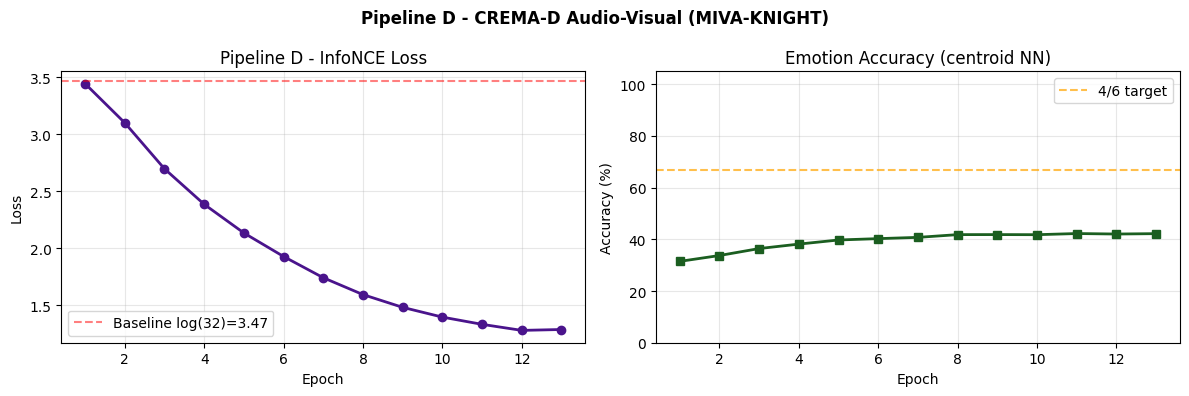

Loss: 3.4425 -> 1.2877  (63% reduction)
Best: epoch 11 @ 42.2%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(all_losses) + 1)

axes[0].plot(ep, all_losses, marker='o', color='#4A148C', linewidth=2)
axes[0].axhline(y=np.log(BATCH_SIZE), color='red', linestyle='--', alpha=0.5,
                label=f'Baseline log({BATCH_SIZE})={np.log(BATCH_SIZE):.2f}')
axes[0].set_title(f'Pipeline D - {"InfoNCE" if CROSS_MODAL else "SupCon"} Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in all_accs], marker='s', color='#1B5E20', linewidth=2)
axes[1].axhline(y=4/6*100, color='orange', linestyle='--', alpha=0.7, label='4/6 target')
axes[1].set_title('Emotion Accuracy (centroid NN)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([0, 105]); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Pipeline D - CREMA-D Audio-Visual (MIVA-KNIGHT)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PIPELINE_D_DIR, 'training_curves_pipelineD.png'), dpi=150)
plt.show()

if all_losses:
    drop = (all_losses[0] - all_losses[-1]) / all_losses[0] * 100
    print(f'Loss: {all_losses[0]:.4f} -> {all_losses[-1]:.4f}  ({drop:.0f}% reduction)')
    print(f'Best: epoch {best_epoch} @ {best_acc*100:.1f}%')

In [22]:
print('Computing CREMA-D emotion centroids from best weights...')
audio_proj.eval()
emotion_embs = defaultdict(list)
with torch.no_grad():
    for audio_batch, _, labels_batch in tqdm(audio_loader, desc='Projecting', leave=False):
        proj = audio_proj(audio_batch.to(device)).cpu()
        for emb, label in zip(proj, labels_batch):
            emotion_embs[CREMA_LABEL_TO_EMOTION[label.item()]].append(emb)
centroids_list = []
print(f"\n{'Emotion':<12} {'Samples':>8} {'Norm':>8}")
print('-' * 30)
for emotion in CREMA_EMOTIONS_6:
    stack    = torch.stack(emotion_embs[emotion])
    centroid = F.normalize(stack.mean(dim=0), p=2, dim=0)
    centroids_list.append(centroid)
    print(f'  {emotion:<10}  {len(stack):>6}   {centroid.norm().item():.4f}')
centroids_tensor = torch.stack(centroids_list)
CENTROIDS_PATH = os.path.join(PIPELINE_D_DIR, 'emotion_centroids_cremad.pt')
torch.save(centroids_tensor, CENTROIDS_PATH)
print(f'\nSaved: {CENTROIDS_PATH}')
print(f'Shape: {list(centroids_tensor.shape)}')

Computing CREMA-D emotion centroids from best weights...


Projecting:   0%|          | 0/232 [00:00<?, ?it/s]


Emotion       Samples     Norm
------------------------------
  angry         1267   1.0000
  disgust       1268   1.0000
  fearful       1268   1.0000
  happy         1267   1.0000
  neutral       1086   1.0000
  sad           1268   1.0000

Saved: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineD/emotion_centroids_cremad.pt
Shape: [6, 512]


In [23]:
print('Saving all Pipeline D outputs to Drive...')

ap_path = os.path.join(PIPELINE_D_DIR, 'audio_projection_cremad.pth')
torch.save({
    'model_state_dict': audio_proj.state_dict(),
    'wav2vec_dim'     : WAV2VEC_DIM,
    'embed_dim'       : EMBED_DIM,
    'best_epoch'      : best_epoch,
    'best_accuracy'   : best_acc,
    'pipeline'        : 'D-CREMAD-v3',
    'warm_start'      : 'Pipeline-C' if WARM_START else 'random',
    'training_mode'   : 'cross-modal-InfoNCE' if CROSS_MODAL else 'audio-only-SupCon',
}, ap_path)
print(f'audio_projection_cremad.pth  ({os.path.getsize(ap_path)/1e6:.1f} MB)')

vp_path = os.path.join(PIPELINE_D_DIR, 'video_frame_projection.pth')
torch.save({
    'model_state_dict': video_proj.state_dict(),
    'resnet_dim'      : RESNET_DIM,
    'embed_dim'       : EMBED_DIM,
    'pipeline'        : 'D-CREMAD-v3',
}, vp_path)
print(f'video_frame_projection.pth   ({os.path.getsize(vp_path)/1e6:.1f} MB)')

config = {
    'pipeline'             : 'D - CREMA-D Audio-Visual MER',
    'data_source'          : 'Local Drive: Data/Crema-d/ (91 Actor folders, .mp4 files)',
    'dataset'              : f'CREMA-D ({len(crema_dataset):,} clips, 91 actors, 6 emotions)',
    'training_mode'        : 'cross-modal InfoNCE' if CROSS_MODAL else 'audio-only SupCon',
    'wav2vec_frozen'       : True,
    'resnet_frozen'        : True,
    'wav2vec_dim'          : WAV2VEC_DIM,
    'embed_dim'            : EMBED_DIM,
    'epochs'               : NUM_EPOCHS,
    'batch_size'           : BATCH_SIZE,
    'learning_rate'        : LEARNING_RATE,
    'temperature'          : TEMPERATURE,
    'warm_start'           : WARM_START,
    'best_epoch'           : best_epoch,
    'best_accuracy'        : round(best_acc, 4),
    'final_loss'           : round(all_losses[-1], 6) if all_losses else None,
    'emotions'             : CREMA_EMOTIONS_6,
    'per_emotion_accuracy' : {e: round(a, 4) for e, a in per_emotion_acc.items()},
    'n_emotions_correct'   : n_correct,
    'pipeline_c_comparison': 'RAVDESS: 6/8 @ 59.0% (SupCon, 1440 clips)',
}
with open(os.path.join(PIPELINE_D_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print('config.json saved')

print(f'\nAll files in {PIPELINE_D_DIR}:')
for fname in sorted(os.listdir(PIPELINE_D_DIR)):
    fpath = os.path.join(PIPELINE_D_DIR, fname)
    print(f'  {fname:<52} {os.path.getsize(fpath)/1e6:6.1f} MB')

Saving all Pipeline D outputs to Drive...
audio_projection_cremad.pth  (4.0 MB)
video_frame_projection.pth   (104.9 MB)
config.json saved

All files in /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineD:
  audio_projection_cremad.pth                             4.0 MB
  checkpoint_pipelineD_latest.pth                       137.7 MB
  config.json                                             0.0 MB
  emotion_centroids_cremad.pt                             0.0 MB
  training_curves_pipelineD.png                           0.1 MB
  video_frame_projection.pth                            104.9 MB


In [24]:
print('=' * 60)
print('ALL 4 PIPELINES COMPLETE')
print('=' * 60)
print()
print('A - COCO    : done Month 1  | TextProjection epoch 15')
print('B - ROCO    : done Month 4  | P@1=64.6%, MRR=0.727')
print('C - RAVDESS : done          | 6/8 emotions @ 59.0%')
print(f'D - CREMA-D : done          | {n_correct}/6 emotions @ {final_acc*100:.1f}%')
print()
print('Pending fixes before Month 6 evaluation:')
print('  1. domain_config.py -> audio_weights: pipelineC/audio_projection.pth')
print('  2. domain_config.py -> emotion_centroids: pipelineC/emotion_centroids.pt')
print('  3. pipeline.py -> AudioProjection(wav2vec_dim=768) [currently 512]')
print('  4. encoders.py -> verify live Wav2Vec path outputs 768d')

ALL 4 PIPELINES COMPLETE

A - COCO    : done Month 1  | TextProjection epoch 15
B - ROCO    : done Month 4  | P@1=64.6%, MRR=0.727
C - RAVDESS : done          | 6/8 emotions @ 59.0%
D - CREMA-D : done          | 1/6 emotions @ 42.2%

Pending fixes before Month 6 evaluation:
  1. domain_config.py -> audio_weights: pipelineC/audio_projection.pth
  2. domain_config.py -> emotion_centroids: pipelineC/emotion_centroids.pt
  3. pipeline.py -> AudioProjection(wav2vec_dim=768) [currently 512]
  4. encoders.py -> verify live Wav2Vec path outputs 768d
